# 02 — Exploration des données formattées (Yahoo Finance)

Lecture du fichier `formatted/yahoofinance/wti.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_yfinance.py`.

In [34]:
import io
import os
import boto3
import pandas as pd

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du parquet formatté (dossier Spark) ──
# Spark écrit un dossier wti.parquet/ contenant _SUCCESS + part-*.parquet
prefix = "formatted/yahoofinance/wti.parquet/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_key = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")][0]

response = s3.get_object(Bucket="datalake", Key=parquet_key)
df = pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow")

print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nPlage : {df['Datetime'].min()} → {df['Datetime'].max()}")
df.head()

Shape : 537 lignes × 8 colonnes

Types :
Datetime            datetime64[ns]
Close                      float64
High                       float64
Low                        float64
Open                       float64
Volume                       int64
Volatility_Range           float64
Variation_Pct              float64
dtype: object

Plage : 2026-02-19 05:00:00 → 2026-02-27 01:00:00


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
0,2026-02-19 05:00:00,65.290001,65.309998,65.220001,65.220001,251,0.09,NaN
1,2026-02-19 05:15:00,65.260002,65.320000,65.230003,65.290001,422,0.09,-0.0459
2,2026-02-19 05:30:00,65.220001,65.269997,65.199997,65.269997,431,0.07,-0.0613
3,2026-02-19 05:45:00,65.230003,65.239998,65.190002,65.220001,235,0.05,0.0153
4,2026-02-19 06:00:00,65.220001,65.260002,65.190002,65.239998,223,0.07,-0.0153


In [35]:
# ── Vérification qualité ──
print("Valeurs manquantes :")
print(df.isnull().sum())
print(f"\nDoublons sur Datetime : {df.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques :")
df.describe().round(2)

Valeurs manquantes :
Datetime            0
Close               0
High                0
Low                 0
Open                0
Volume              0
Volatility_Range    0
Variation_Pct       1
dtype: int64

Doublons sur Datetime : 0

Statistiques :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
count,537,537.00,537.00,537.00,537.00,537.00,537.00,536.00
mean,2026-02-23 12:22:07.374301696,66.03,66.12,65.92,66.03,3778.51,0.20,-0.00
min,2026-02-19 05:00:00,63.71,64.13,63.60,63.71,0.00,0.03,-1.13
25%,2026-02-20 15:30:00,65.68,65.76,65.61,65.68,752.00,0.11,-0.09
50%,2026-02-24 03:00:00,66.09,66.19,65.98,66.09,1772.00,0.16,0.00
75%,2026-02-25 13:30:00,66.42,66.53,66.31,66.42,5063.00,0.24,0.10
max,2026-02-27 01:00:00,67.24,67.28,67.12,67.25,46560.00,1.52,0.90
std,NaN,0.56,0.56,0.57,0.56,5019.98,0.14,0.21


In [36]:
# ── Aperçu dernières lignes ──
print("Dernières lignes :")
df.tail(50)

Dernières lignes :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
487,2026-02-26 11:45:00,64.309998,64.389999,64.279999,64.360001,1115,0.11,-0.0777
488,2026-02-26 12:00:00,64.339996,64.440002,64.250000,64.309998,1941,0.19,0.0466
489,2026-02-26 12:15:00,64.099998,64.339996,63.810001,64.330002,9128,0.53,-0.3730
490,2026-02-26 12:30:00,64.139999,64.239998,64.080002,64.089996,4493,0.16,0.0624
491,2026-02-26 12:45:00,64.120003,64.190002,64.059998,64.139999,3365,0.13,-0.0312
492,2026-02-26 13:00:00,63.709999,64.129997,63.689999,64.129997,7808,0.44,-0.6394
493,2026-02-26 13:15:00,64.129997,64.150002,63.599998,63.709999,10141,0.55,0.6592
494,2026-02-26 13:30:00,64.480003,64.480003,64.099998,64.139999,7010,0.38,0.5458
495,2026-02-26 13:45:00,64.379997,64.489998,64.260002,64.480003,5941,0.23,-0.1551
496,2026-02-26 14:00:00,64.279999,64.470001,64.199997,64.370003,9696,0.27,-0.1553


---
# Exploration des données formattées (GDELT)

Lecture du fichier `formatted/gdelt/events.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_gdelt.py`.

In [37]:
# ═══════════════════════════════════════════════
# Chargement du Parquet formatté GDELT depuis S3
# ═══════════════════════════════════════════════
prefix_gdelt = "formatted/gdelt/events.parquet/"
objs_gdelt = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gdelt)
parquet_keys_gdelt = [o["Key"] for o in objs_gdelt.get("Contents", []) if o["Key"].endswith(".parquet")]

# Spark peut écrire plusieurs partitions → on les concat
dfs = []
for key in parquet_keys_gdelt:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gdelt = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Shape : {df_gdelt.shape[0]} lignes × {df_gdelt.shape[1]} colonnes")
print(f"\nTypes :\n{df_gdelt.dtypes}")
print(f"\nColonnes : {list(df_gdelt.columns)}")
df_gdelt.head()

Shape : 106836 lignes × 23 colonnes

Types :
GlobalEventID                     int64
Day                              object
DATEADDED                datetime64[ns]
Actor1Code                       object
Actor1Name                       object
Actor1CountryCode                object
Actor1Type1Code                  object
Actor2Code                       object
Actor2Name                       object
Actor2CountryCode                object
Actor2Type1Code                  object
EventCode                         int32
EventRootCode                     int32
QuadClass                         int32
GoldsteinScale                  float64
IsRootEvent                       int32
ActionGeo_CountryCode            object
ActionGeo_Lat                   float64
ActionGeo_Long                  float64
NumMentions                       int32
NumSources                        int32
NumArticles                       int32
AvgTone                         float64
dtype: object

Colonnes : ['GlobalE

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone
0,1289876163,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,2,6.4,1,US,42.1497,-74.9384,8,2,8,-1.852742
1,1289876173,2025-02-19,2026-02-18 23:00:00,MNCUSA,MICROSOFT,USA,MNC,None,None,None,...,4,-10.0,1,IN,28.6000,77.2000,10,1,10,1.020408
2,1289876199,2026-02-12,2026-02-18 23:00:00,LAB,EMPLOYEE,None,LAB,USA,UNITED STATES,USA,...,4,-5.0,1,US,34.0983,-118.3270,6,1,6,-2.110818
3,1289876202,2026-02-12,2026-02-18 23:00:00,USACOP,ALABAMA,USA,COP,None,None,None,...,4,-10.0,1,US,33.2668,-86.6666,6,1,6,1.403509
4,1289876245,2026-02-19,2026-02-18 23:00:00,None,None,None,None,CHRCTH,CATHOLIC,None,...,3,-5.0,1,EI,53.0000,-8.0000,6,1,6,-1.624815


In [38]:
# ═══════════════════════════════════════════════
# Statistiques descriptives GDELT
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gdelt.isnull().sum())
print(f"\nDoublons sur GlobalEventID : {df_gdelt.duplicated(subset=['GlobalEventID']).sum()}")
print(f"\nPlage temporelle : {df_gdelt['DATEADDED'].min()} → {df_gdelt['DATEADDED'].max()}")
print(f"\nStatistiques numériques :")
df_gdelt.describe().round(2)

Valeurs manquantes :
GlobalEventID                0
Day                          0
DATEADDED                    0
Actor1Code               11461
Actor1Name               11461
Actor1CountryCode        55692
Actor1Type1Code          54383
Actor2Code               36365
Actor2Name               36365
Actor2CountryCode        69359
Actor2Type1Code          68589
EventCode                    0
EventRootCode                0
QuadClass                    0
GoldsteinScale               0
IsRootEvent                  0
ActionGeo_CountryCode     6968
ActionGeo_Lat             7017
ActionGeo_Long            6990
NumMentions                  0
NumSources                   0
NumArticles                  0
AvgTone                      0
dtype: int64

Doublons sur GlobalEventID : 0

Plage temporelle : 2026-02-18 23:00:00 → 2026-02-27 00:15:00

Statistiques numériques :


,GlobalEventID,DATEADDED,EventCode,EventRootCode,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone
count,1.068360e+05,106836,106836.00,106836.00,106836.00,106836.00,106836.00,99819.00,99846.00,106836.00,106836.00,106836.00,106836.00
mean,1.290580e+09,2026-02-23 03:50:34.623160576,238.41,14.17,3.32,-3.77,0.62,31.21,-9.83,7.28,1.08,7.08,-3.94
min,1.289876e+09,2026-02-18 23:00:00,60.00,6.00,2.00,-10.00,0.00,-85.62,-179.77,4.00,1.00,4.00,-31.25
25%,1.290231e+09,2026-02-20 18:30:00,100.00,8.00,2.00,-9.50,0.00,25.00,-83.49,5.00,1.00,4.00,-6.71
50%,1.290589e+09,2026-02-23 14:15:00,173.00,17.00,4.00,-5.00,1.00,35.74,-0.12,6.00,1.00,6.00,-3.88
75%,1.290927e+09,2026-02-25 07:45:00,190.00,19.00,4.00,5.00,1.00,42.44,49.88,10.00,1.00,10.00,-1.17
max,1.291279e+09,2026-02-27 00:15:00,1832.00,20.00,4.00,10.00,1.00,81.50,179.48,310.00,17.00,310.00,16.42
std,4.064978e+05,NaN,318.17,4.83,0.87,6.45,0.49,20.20,79.04,4.66,0.53,4.24,4.23


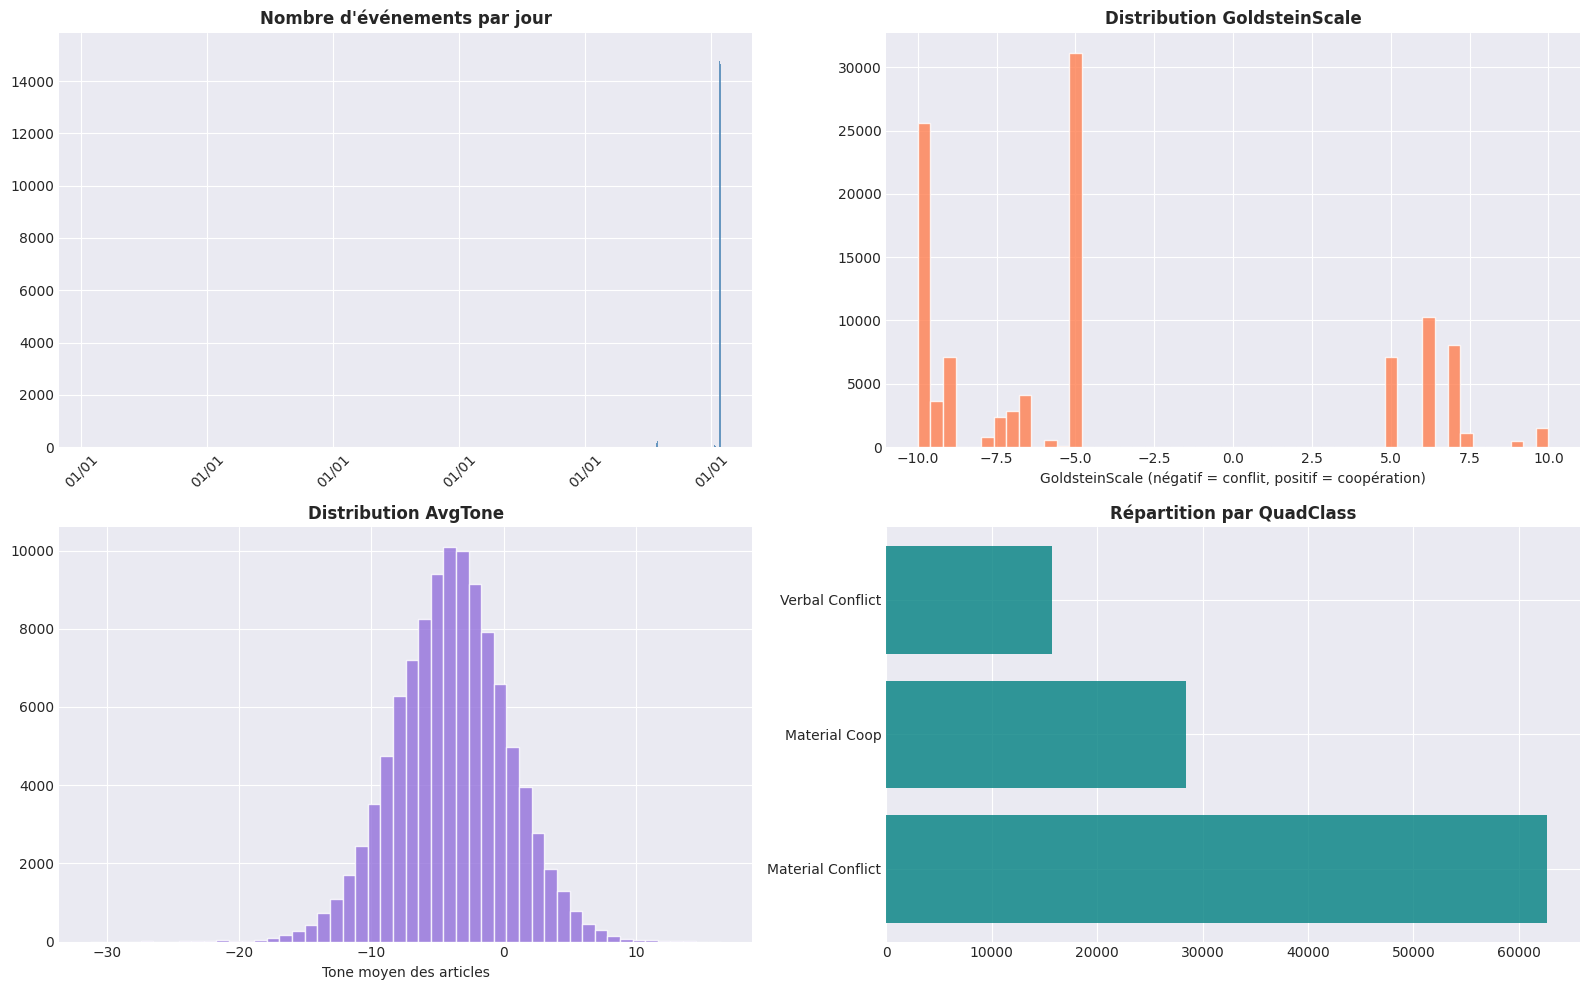

In [39]:
# ═══════════════════════════════════════════════
# Distribution des événements GDELT
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Nombre d'événements par jour
if "Day" in df_gdelt.columns:
    df_gdelt["Day_dt"] = pd.to_datetime(df_gdelt["Day"], format="%Y%m%d", errors="coerce")
    daily = df_gdelt.groupby("Day_dt").size()
    axes[0, 0].bar(daily.index, daily.values, color="steelblue", alpha=0.8)
    axes[0, 0].set_title("Nombre d'événements par jour", fontweight="bold")
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Distribution GoldsteinScale
if "GoldsteinScale" in df_gdelt.columns:
    axes[0, 1].hist(df_gdelt["GoldsteinScale"].dropna(), bins=50, color="coral", alpha=0.8, edgecolor="white")
    axes[0, 1].set_title("Distribution GoldsteinScale", fontweight="bold")
    axes[0, 1].set_xlabel("GoldsteinScale (négatif = conflit, positif = coopération)")

# 3. Distribution AvgTone
if "AvgTone" in df_gdelt.columns:
    axes[1, 0].hist(df_gdelt["AvgTone"].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[1, 0].set_title("Distribution AvgTone", fontweight="bold")
    axes[1, 0].set_xlabel("Tone moyen des articles")

# 4. Top 10 QuadClass
if "QuadClass" in df_gdelt.columns:
    top_quad = df_gdelt["QuadClass"].value_counts().head(10)
    quad_labels = {1: "Verbal Coop", 2: "Material Coop", 3: "Verbal Conflict", 4: "Material Conflict"}
    top_quad.index = [quad_labels.get(int(x), str(x)) for x in top_quad.index]
    axes[1, 1].barh(top_quad.index, top_quad.values, color="teal", alpha=0.8)
    axes[1, 1].set_title("Répartition par QuadClass", fontweight="bold")

plt.tight_layout()
plt.show()

In [40]:
# ═══════════════════════════════════════════════
# Aperçu dernières lignes GDELT
# ═══════════════════════════════════════════════
print(f"Dernières lignes :")
df_gdelt.tail(200)

Dernières lignes :


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
106636,1291277754,2026-02-27,2026-02-27 00:15:00,None,None,None,None,JPN,JAPAN,JPN,...,10.0,1,JA,35.166700,136.9170,6,1,6,6.336634,2026-02-27
106637,1291277765,2026-02-27,2026-02-27 00:15:00,None,None,None,None,LEG,REPRESENTATIVES,None,...,-10.0,0,None,NaN,NaN,10,1,10,-0.447094,2026-02-27
106638,1291277826,2026-02-27,2026-02-27 00:15:00,None,None,None,None,USA,UNITED STATES,USA,...,-5.0,1,US,39.529600,-119.8140,8,1,8,-6.511628,2026-02-27
106639,1291277888,2026-02-27,2026-02-27 00:15:00,AUS,SYDNEY,AUS,None,None,None,None,...,-9.0,1,AS,-23.650000,149.3330,8,1,8,0.814664,2026-02-27
106640,1291277929,2026-02-27,2026-02-27 00:15:00,BUS,INVESTOR,None,BUS,None,None,None,...,-5.0,1,US,39.828175,-98.5795,10,1,10,5.289673,2026-02-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106831,1291279061,2026-02-27,2026-02-27 00:15:00,USA,UNITED STATES,USA,None,VEN,VENEZUELA,VEN,...,-9.5,1,VE,10.500000,-66.9167,5,1,5,-0.523560,2026-02-27
106832,1291279071,2026-02-27,2026-02-27 00:15:00,USACVL,CATO INSTITUTE,USA,CVL,CRM,CRIMINAL,None,...,-5.0,0,US,40.735700,-74.1724,4,1,4,-5.324074,2026-02-27
106833,1291279121,2026-02-27,2026-02-27 00:15:00,USALEG,MAINE,USA,LEG,CVL,LANDOWNER,None,...,6.0,1,US,44.607400,-69.3977,12,1,6,-2.710843,2026-02-27
106834,1291279159,2026-02-27,2026-02-27 00:15:00,balSEP,BALOCH,None,SEP,None,None,None,...,-5.0,0,PK,33.700000,73.1667,8,1,8,-7.438017,2026-02-27


In [41]:
# ═══════════════════════════════════════════════
# Affichage des 20 premières lignes GDELT
# ═══════════════════════════════════════════════
df_gdelt.head(100)

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
0,1289876163,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,6.4,1,US,42.1497,-74.9384,8,2,8,-1.852742,2025-02-19
1,1289876173,2025-02-19,2026-02-18 23:00:00,MNCUSA,MICROSOFT,USA,MNC,None,None,None,...,-10.0,1,IN,28.6000,77.2000,10,1,10,1.020408,2025-02-19
2,1289876199,2026-02-12,2026-02-18 23:00:00,LAB,EMPLOYEE,None,LAB,USA,UNITED STATES,USA,...,-5.0,1,US,34.0983,-118.3270,6,1,6,-2.110818,2026-02-12
3,1289876202,2026-02-12,2026-02-18 23:00:00,USACOP,ALABAMA,USA,COP,None,None,None,...,-10.0,1,US,33.2668,-86.6666,6,1,6,1.403509,2026-02-12
4,1289876245,2026-02-19,2026-02-18 23:00:00,None,None,None,None,CHRCTH,CATHOLIC,None,...,-5.0,1,EI,53.0000,-8.0000,6,1,6,-1.624815,2026-02-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1289876609,2026-02-19,2026-02-18 23:00:00,AUS,AUSTRALIA,AUS,None,MNCUSAMED,NEWS CORP,USA,...,-5.0,1,AS,-25.0000,135.0000,10,1,10,0.162866,2026-02-19
96,1289876761,2026-02-19,2026-02-18 23:00:00,CHE,GENEVA,CHE,None,None,None,None,...,-9.0,1,US,42.7475,-107.2090,8,1,8,-4.326123,2026-02-19
97,1289876798,2026-02-19,2026-02-18 23:00:00,CHR,CHRISTIAN,None,None,None,None,None,...,5.0,1,US,38.5111,-96.8005,10,1,10,1.981707,2026-02-19
98,1289876845,2026-02-19,2026-02-18 23:00:00,COP,POLICE,None,COP,None,None,None,...,-9.2,1,US,41.8787,-71.3826,10,1,10,-5.432099,2026-02-19


In [42]:
print(df_gdelt.iloc[110])

GlobalEventID                     1289877256
Day                               2026-02-19
DATEADDED                2026-02-18 23:00:00
Actor1Code                               GOV
Actor1Name                       AUTHORITIES
Actor1CountryCode                       None
Actor1Type1Code                          GOV
Actor2Code                              None
Actor2Name                              None
Actor2CountryCode                       None
Actor2Type1Code                         None
EventCode                                180
EventRootCode                             18
QuadClass                                  4
GoldsteinScale                          -9.0
IsRootEvent                                0
ActionGeo_CountryCode                     US
ActionGeo_Lat                         31.106
ActionGeo_Long                      -97.6475
NumMentions                                6
NumSources                                 1
NumArticles                                6
AvgTone   

In [43]:
# Filtrer les lignes avec OPC en Actor1Code ou Actor2Code
df_opc = df_gdelt[(df_gdelt['Actor1Code'] == 'GOVOPC') | (df_gdelt['Actor2Code'] == 'GOVOPC')]

print(f"Nombre de lignes avec OPC : {len(df_opc)}")
df_opc.head(50)

Nombre de lignes avec OPC : 0


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt


In [44]:
import numpy as np

# ═══════════════════════════════════════════════
# Ajout des colonnes "buzz" et "gravité pondérée"
# ═══════════════════════════════════════════════


# Création d'une copie du dataset filtré pour ajouter les nouvelles colonnes
df_gdelt_enriched = filter_all.copy()

# Calcul de "Le buzz" : log(1 + NumArticles)
df_gdelt_enriched['buzz'] = np.log(1 + df_gdelt_enriched['NumArticles'])

# Calcul de "La Gravité pondérée" : (10 - Goldstein) × (1 + (100 - AvgTone) / 50)
df_gdelt_enriched['gravite_ponderee'] = (
    (10 - df_gdelt_enriched['GoldsteinScale']) * 
    (1 + (100 - df_gdelt_enriched['AvgTone']) / 50)
)

print(f"✅ Nouvelles colonnes ajoutées : 'buzz' et 'gravite_ponderee'")
print(f"📊 Shape du dataset enrichi : {df_gdelt_enriched.shape[0]} lignes × {df_gdelt_enriched.shape[1]} colonnes\n")
print("=" * 150)
print("Aperçu des 100 premières lignes :\n")
df_gdelt_enriched.head(100)
df_gdelt_enriched.describe()


NameError: name 'filter_all' is not defined

In [ ]:
# ═══════════════════════════════════════════════
# Analyse de l'impact des filtres avec EventRootCode
# ═══════════════════════════════════════════════

relevant_event_codes = [6, 8,10,11,12, 13, 14, 15, 16, 17, 18, 19, 20]

df_base = df_gdelt.copy()
total = len(df_base)

# Calcul de chaque filtre individuellement
f_eventroot = df_base['EventRootCode'].isin(relevant_event_codes)
f_numart    = df_base['NumArticles'] >= 4
f_goldstein = df_base['GoldsteinScale'].abs() >= 5
f_quadclass = df_base['QuadClass'] >= 2

# Construction du tableau d'impact
filters_summary = [
    ("Aucun filtre (données initiales)",                       total),
    ("EventRootCode ∈ liste",                                  f_eventroot.sum()),
    ("NumArticles >= 4",                                       f_numart.sum()),
    ("|GoldsteinScale| >= 5",                                  f_goldstein.sum()),
    ("QuadClass >= 2",                                         f_quadclass.sum()),
    ("EventRootCode ∈ liste ET NumArticles >= 4",              (f_eventroot & f_numart).sum()),
    ("EventRootCode ∈ liste ET |GoldsteinScale| >= 5",         (f_eventroot & f_goldstein).sum()),
    ("EventRootCode ∈ liste ET QuadClass >= 2",                (f_eventroot & f_quadclass).sum()),
    ("NumArticles >= 4 ET |GoldsteinScale| >= 5",              (f_numart & f_goldstein).sum()),
    ("NumArticles >= 4 ET QuadClass >= 2",                     (f_numart & f_quadclass).sum()),
    ("|GoldsteinScale| >= 5 ET QuadClass >= 2",                (f_goldstein & f_quadclass).sum()),
    ("TOUS LES FILTRES COMBINÉS",                              (f_numart & f_goldstein & f_quadclass).sum()),
]

results_extended = pd.DataFrame(filters_summary, columns=["Filtre(s) appliqué(s)", "Nombre de lignes"])
results_extended["% restant"]  = (results_extended["Nombre de lignes"] / total * 100).round(2)
results_extended["Lignes retirées"] = total - results_extended["Nombre de lignes"]
results_extended["% retiré"]   = (results_extended["Lignes retirées"] / total * 100).round(2)

print(f"Total initial : {total:,} lignes\n")
print(f"Codes EventRootCode conservés : {relevant_event_codes}\n")
display(results_extended)

# Aperçu du dataset final avec tous les filtres combinés
df_final = df_base[f_numart & f_goldstein & f_quadclass].copy()
print(f"\n✅ Dataset final (tous filtres) : {len(df_final):,} lignes × {df_final.shape[1]} colonnes")
df_final.head(20)

In [45]:
# Affichage des 20 premières lignes du GDELT
df_gdelt.head(20)

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
0,1289876163,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,6.4,1,US,42.149700,-74.9384,8,2,8,-1.852742,2025-02-19
1,1289876173,2025-02-19,2026-02-18 23:00:00,MNCUSA,MICROSOFT,USA,MNC,None,None,None,...,-10.0,1,IN,28.600000,77.2000,10,1,10,1.020408,2025-02-19
2,1289876199,2026-02-12,2026-02-18 23:00:00,LAB,EMPLOYEE,None,LAB,USA,UNITED STATES,USA,...,-5.0,1,US,34.098300,-118.3270,6,1,6,-2.110818,2026-02-12
3,1289876202,2026-02-12,2026-02-18 23:00:00,USACOP,ALABAMA,USA,COP,None,None,None,...,-10.0,1,US,33.266800,-86.6666,6,1,6,1.403509,2026-02-12
4,1289876245,2026-02-19,2026-02-18 23:00:00,None,None,None,None,CHRCTH,CATHOLIC,None,...,-5.0,1,EI,53.000000,-8.0000,6,1,6,-1.624815,2026-02-19
5,1289876260,2026-02-19,2026-02-18 23:00:00,None,None,None,None,COP,TROOPER,None,...,-5.0,1,US,32.799000,-86.8073,10,1,10,-7.729469,2026-02-19
6,1289876332,2026-02-19,2026-02-18 23:00:00,None,None,None,None,GOV,AUTHORITIES,None,...,7.0,1,US,34.852600,-82.3940,6,1,6,-6.682028,2026-02-19
7,1289876384,2026-02-19,2026-02-18 23:00:00,None,None,None,None,MED,WEBSITE,None,...,-10.0,0,US,45.732600,-93.9196,8,1,8,-7.777778,2026-02-19
8,1289876500,2026-02-19,2026-02-18 23:00:00,None,None,None,None,USA,UNITED STATES,USA,...,-5.0,1,US,36.170000,-119.7460,4,1,4,-1.920236,2026-02-19
9,1289876518,2026-02-19,2026-02-18 23:00:00,None,None,None,None,USA,UNITED STATES,USA,...,-5.0,0,US,46.175100,-122.9220,4,1,4,-8.011869,2026-02-19
